<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keenam/blob/main/Restorasi_Citra_MG_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving WhatsApp Image 2023-08-20 at 08.46.36.jpeg to WhatsApp Image 2023-08-20 at 08.46.36.jpeg
✅ Gambar berhasil dimuat: WhatsApp Image 2023-08-20 at 08.46.36.jpeg

=== Motion Blur ===
Inverse -> PSNR: 28.09, SSIM: 0.012, MSE: 100.85, Time: 0.0081s


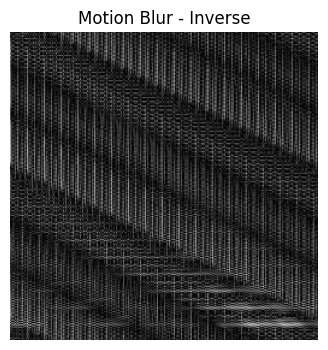

Wiener -> PSNR: 28.83, SSIM: 0.207, MSE: 85.20, Time: 0.0080s


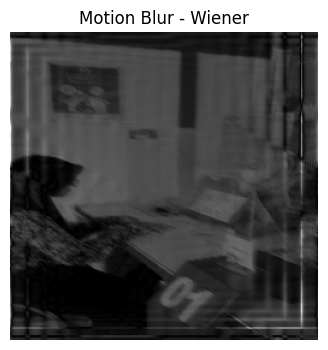

RL -> PSNR: 31.53, SSIM: 0.792, MSE: 45.71, Time: 0.2883s


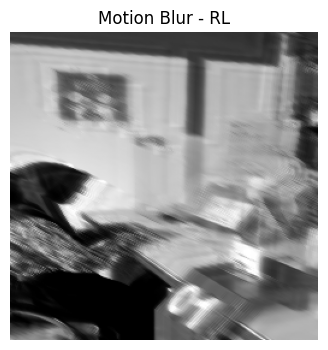


=== Gaussian+Blur ===
Inverse -> PSNR: 28.13, SSIM: 0.055, MSE: 99.94, Time: 0.0046s


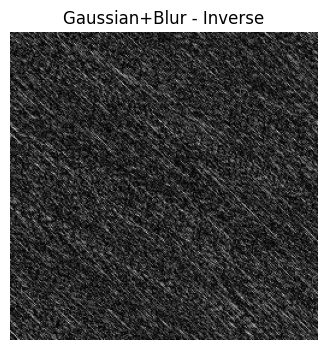

Wiener -> PSNR: 27.91, SSIM: 0.015, MSE: 105.23, Time: 0.0057s


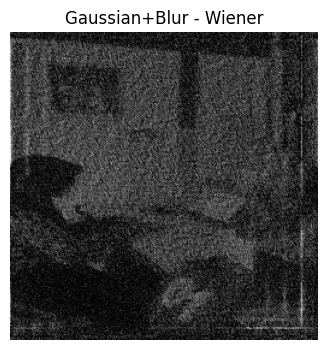

RL -> PSNR: 28.33, SSIM: 0.219, MSE: 95.58, Time: 0.2919s


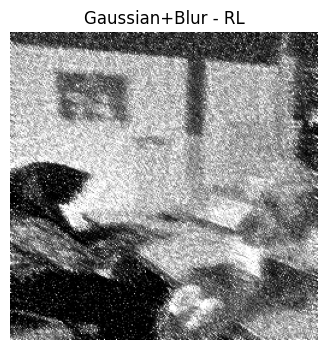


=== SaltPepper+Blur ===
Inverse -> PSNR: 28.14, SSIM: 0.145, MSE: 99.74, Time: 0.0046s


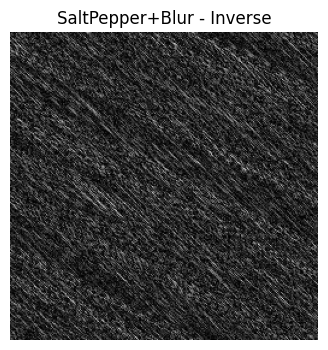

Wiener -> PSNR: 27.95, SSIM: 0.007, MSE: 104.27, Time: 0.0054s


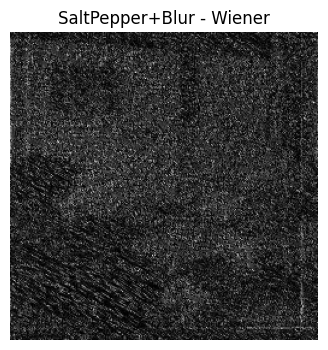

RL -> PSNR: 28.25, SSIM: 0.116, MSE: 97.38, Time: 0.2754s


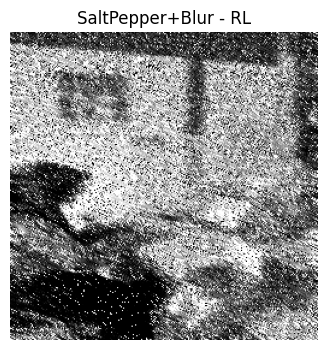

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from skimage.metrics import structural_similarity as ssim
from google.colab import files

# =========================
# 1. UPLOAD GAMBAR (ANTI ERROR)
# =========================
uploaded = files.upload()

# Ambil nama file pertama yang diupload
file_name = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(file_name, 0)

# Cek apakah gambar berhasil dibaca
if img is None:
    raise ValueError("❌ Gambar gagal dibaca! Pastikan format benar (jpg/png).")

# Resize gambar
img = cv2.resize(img, (256, 256))

print("✅ Gambar berhasil dimuat:", file_name)

# =========================
# 2. PSF MOTION BLUR
# =========================
def motion_psf(length=15, angle=30):
    psf = np.zeros((length, length))
    center = length // 2
    angle_rad = np.deg2rad(angle)

    x1 = int(center - (length/2)*np.cos(angle_rad))
    y1 = int(center - (length/2)*np.sin(angle_rad))
    x2 = int(center + (length/2)*np.cos(angle_rad))
    y2 = int(center + (length/2)*np.sin(angle_rad))

    cv2.line(psf, (x1,y1), (x2,y2), 1, 1)
    psf /= psf.sum()
    return psf

psf = motion_psf()

# =========================
# 3. DEGRADASI
# =========================
# Motion blur
blur = cv2.filter2D(img.astype(float), -1, psf)

# Gaussian noise + blur
gaussian_noise = np.random.normal(0, 20, blur.shape)
blur_gauss = np.clip(blur + gaussian_noise, 0, 255)

# Salt & pepper + blur
sp = blur.copy()
prob = 0.05
num = int(prob * img.size)

coords = [np.random.randint(0, i, num) for i in img.shape]
sp[coords[0], coords[1]] = 255

coords = [np.random.randint(0, i, num) for i in img.shape]
sp[coords[0], coords[1]] = 0

blur_sp = sp

# =========================
# 4. INVERSE FILTER
# =========================
def inverse_filter(degraded, psf, eps=1e-3):
    G = np.fft.fft2(degraded)
    H = np.fft.fft2(psf, s=degraded.shape)
    F = G / (H + eps)
    return np.abs(np.fft.ifft2(F))

# =========================
# 5. WIENER FILTER
# =========================
def wiener_filter(degraded, psf, K=0.01):
    G = np.fft.fft2(degraded)
    H = np.fft.fft2(psf, s=degraded.shape)

    H_conj = np.conj(H)
    F = (H_conj / (np.abs(H)**2 + K)) * G
    return np.abs(np.fft.ifft2(F))

# =========================
# 6. RICHARDSON LUCY
# =========================
def richardson_lucy(image, psf, iterations=20):
    image = image.astype(np.float32)
    estimate = image.copy()
    psf_flip = np.flip(psf)

    for i in range(iterations):
        conv = cv2.filter2D(estimate, -1, psf)
        conv[conv == 0] = 1e-8
        ratio = image / conv
        estimate *= cv2.filter2D(ratio, -1, psf_flip)
        estimate = np.clip(estimate, 0, 255)

    return estimate

# =========================
# 7. METRIK
# =========================
def evaluate(original, result):
    result = np.clip(result, 0, 255).astype(np.uint8)

    mse = np.mean((original - result)**2)
    psnr = 10 * np.log10(255**2 / mse)
    ssim_val = ssim(original, result)

    return mse, psnr, ssim_val

# =========================
# 8. PROSES RESTORASI
# =========================
datasets = {
    "Motion Blur": blur,
    "Gaussian+Blur": blur_gauss,
    "SaltPepper+Blur": blur_sp
}

results = {}

for name, data in datasets.items():
    results[name] = {}

    # Inverse
    start = time.time()
    inv = inverse_filter(data, psf)
    t_inv = time.time() - start

    # Wiener
    start = time.time()
    wien = wiener_filter(data, psf, K=0.01)
    t_wien = time.time() - start

    # RL
    start = time.time()
    rl = richardson_lucy(data, psf, 20)
    t_rl = time.time() - start

    results[name]['Inverse'] = (inv, t_inv)
    results[name]['Wiener'] = (wien, t_wien)
    results[name]['RL'] = (rl, t_rl)

# =========================
# 9. TAMPILKAN HASIL
# =========================
for name, methods in results.items():
    print(f"\n=== {name} ===")

    for method, (img_restored, waktu) in methods.items():
        mse, psnr, ssim_val = evaluate(img, img_restored)

        print(f"{method} -> PSNR: {psnr:.2f}, SSIM: {ssim_val:.3f}, MSE: {mse:.2f}, Time: {waktu:.4f}s")

        plt.figure(figsize=(4,4))
        plt.imshow(img_restored, cmap='gray')
        plt.title(f"{name} - {method}")
        plt.axis('off')
        plt.show()